
To download the dataset, you must first **join the competition** on the Kaggle website.

Steps:

1. Open the **Data Science Bowl 2018** competition page.
2. Click **“Join Competition”** and accept the rules.
3. If you are running the notebook **on Kaggle**, you do NOT need `kaggle.json`.
4. Then run the following command:


In [1]:
!kaggle competitions download -c data-science-bowl-2018 --force

100%|████████████████████████████████████████| 358M/358M [00:09<00:00, 39.9MB/s]



In [2]:
import zipfile
import os

# Step 1: Unzip main file
main_zip = "/kaggle/working/data-science-bowl-2018.zip"
with zipfile.ZipFile(main_zip, 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

print("Main zip extracted!")

# Step 2: Unzip stage1_train.zip into train folder
train_zip = "/kaggle/working/stage1_train.zip"
train_extract_path = "/kaggle/working/train"

os.makedirs(train_extract_path, exist_ok=True)

with zipfile.ZipFile(train_zip, 'r') as zip_ref:
    zip_ref.extractall(train_extract_path)

print("Stage1 train extracted successfully!")

Main zip extracted!
Stage1 train extracted successfully!


# Imports

In [232]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm

In [233]:
DATA_PATH = "/kaggle/working/train"

In [234]:
def load_sample(sample_path):
    
    image_path = glob(os.path.join(sample_path, "images", "*"))[0]
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    mask_paths = glob(os.path.join(sample_path, "masks", "*"))
    
    combined_mask = np.zeros(image.shape[:2], dtype=np.uint8)
    
    for m_path in mask_paths:
        mask = cv2.imread(m_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)   # convert EACH mask to binary
        combined_mask = np.maximum(combined_mask, mask)
    
    return image, combined_mask

In [235]:
def preprocess(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0) # Why blur? Watershed is sensitive to noise.
    return blur

# Watershed Without Markers

In [236]:
def watershed_without_markers(gray):
    
    # Otsu threshold
    _, thresh = cv2.threshold(gray, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Convert to binary (0 and 1)
    return (thresh > 0).astype(np.uint8)

### Why is `threshold()` (Otsu) used?

`threshold()` converts the grayscale image into a **binary image (foreground vs background)**.  
Otsu automatically selects the optimal threshold value based on intensity distribution.

# Marker Controlled Watershed

In [237]:
def watershed_with_markers(gray):
    
    # Step 1: Threshold
    _, thresh = cv2.threshold(gray, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    kernel = np.ones((3,3), np.uint8)
    
    # Step 2: Remove small noise
    opening = cv2.morphologyEx(thresh,
                               cv2.MORPH_OPEN,
                               kernel,
                               iterations=2)
    
    # Step 3: Distance transform
    dist_transform = cv2.distanceTransform(opening,
                                           cv2.DIST_L2,
                                           5)
    
    # Step 4: Sure foreground (nucleus centers)
    _, sure_fg = cv2.threshold(dist_transform,
                               0.4 * dist_transform.max(),
                               255,
                               0)
    
    sure_fg = np.uint8(sure_fg)
    
    # Step 5: Sure background
    sure_bg = cv2.dilate(opening,
                         kernel,
                         iterations=3)
    
    # Step 6: Unknown region
    unknown = cv2.subtract(sure_bg, sure_fg)
    
    # Step 7: Marker labeling
    _, markers = cv2.connectedComponents(sure_fg)
    
    markers = markers + 1
    markers[unknown == 255] = 0
    
    # Step 8: Apply watershed
    markers = cv2.watershed(cv2.cvtColor(gray,
                                         cv2.COLOR_GRAY2BGR),
                            markers)
    
    # Final binary mask (exclude boundaries -1 and background 1)
    final_mask = (markers > 1).astype(np.uint8)
    
    return final_mask

### Why is `threshold()` (Otsu) needed?

`threshold()` converts the grayscale image into a **binary image (nuclei vs background)**.  
Otsu automatically selects the best threshold value.


### Why is `distanceTransform()` needed?

`distanceTransform()` computes how far each white pixel is from the background.  
This helps identify the **center of each nucleus**.


### Why is thresholding the distance transform needed?

Thresholding the distance map extracts only the **strong central regions** of nuclei.  
These act as **sure foreground seeds**.

### Why is `connectedComponents()` needed?

`connectedComponents()` assigns a **unique label to each nucleus center**.  
Watershed uses these labeled regions as starting seeds to separate touching nuclei.

### Why is `watershed()` needed?

`watershed()` grows regions from each labeled seed and creates boundaries where regions meet.  
This properly **separates overlapping or touching nuclei**.

In [238]:
def compute_dice(gt, pred):
    intersection = np.logical_and(gt, pred).sum()
    return (2 * intersection) / (gt.sum() + pred.sum() + 1e-8)

In [239]:
import random

sample_ids = os.listdir(DATA_PATH)
random_id = random.choice(sample_ids)

sample_path = os.path.join(DATA_PATH, random_id)

image, gt_mask = load_sample(sample_path)
gray = preprocess(image)

pred_yes = watershed_with_markers(gray)

print("Sample ID:", random_id)
print("GT sum:", gt_mask.sum())
print("Pred sum:", pred_yes.sum())
print("Unique GT:", np.unique(gt_mask))
print("Unique Pred:", np.unique(pred_yes))

image, gt_mask = load_sample(sample_path)

gray = preprocess(image)

pred_no = watershed_without_markers(gray)
pred_yes = watershed_with_markers(gray)

# Ensure binary masks
gt_mask = (gt_mask > 0).astype(np.uint8)
pred_no = (pred_no > 0).astype(np.uint8)
pred_yes = (pred_yes > 0).astype(np.uint8)

print("Dice Without Markers:", compute_dice(gt_mask, pred_no))
print("Dice With Markers:", compute_dice(gt_mask, pred_yes))

Sample ID: 431b9b0c520a28375b5a0c18d0a5039dd62cbca7c4a0bcc25af3b763d4a81bec
GT sum: 1847
Pred sum: 1230
Unique GT: [0 1]
Unique Pred: [0 1]
Dice Without Markers: 0.8838973162167915
Dice With Markers: 0.7936301592434396


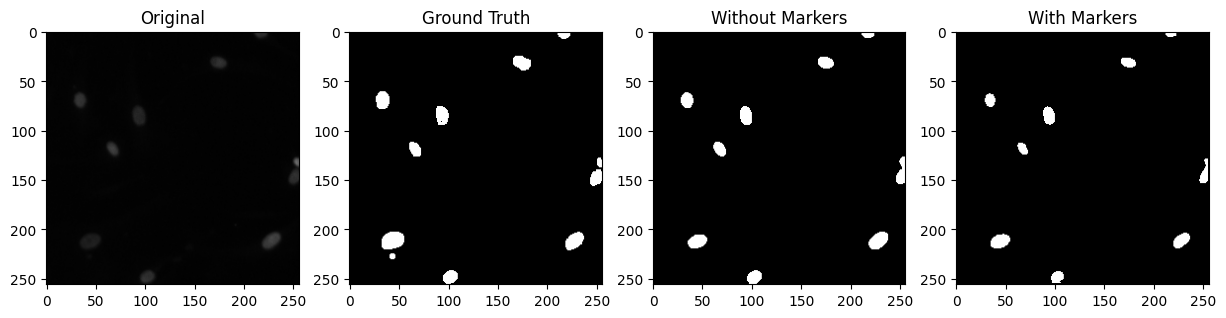

In [240]:
plt.figure(figsize=(15,6))

plt.subplot(1,4,1)
plt.imshow(image)
plt.title("Original")

plt.subplot(1,4,2)
plt.imshow(gt_mask, cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,4,3)
plt.imshow(pred_no, cmap='gray')
plt.title("Without Markers")

plt.subplot(1,4,4)
plt.imshow(pred_yes, cmap='gray')
plt.title("With Markers")

plt.show()

In [241]:
def evaluate_dataset(limit=100):
    
    dice_no = []
    dice_yes = []
    
    sample_ids = os.listdir(DATA_PATH)[:limit]
    
    for sid in tqdm(sample_ids):
        sample_path = os.path.join(DATA_PATH, sid)
        
        image, gt_mask = load_sample(sample_path)
        gray = preprocess(image)
        
        pred_no = watershed_without_markers(gray)
        pred_yes = watershed_with_markers(gray)
        
        # Ensure binary masks
        gt_mask = (gt_mask > 0).astype(np.uint8)
        pred_no = (pred_no > 0).astype(np.uint8)
        pred_yes = (pred_yes > 0).astype(np.uint8)
        
        dice_no.append(compute_dice(gt_mask, pred_no))
        dice_yes.append(compute_dice(gt_mask, pred_yes))
    
    return np.mean(dice_no), np.mean(dice_yes)

In [242]:
mean_no, mean_yes = evaluate_dataset(limit=1000)

print(f"Average Dice Without Markers: {mean_no:.4f}")
print(f"Average Dice With Markers: {mean_yes:.4f}")

100%|██████████| 670/670 [00:41<00:00, 16.11it/s]

Average Dice Without Markers: 0.7293
Average Dice With Markers: 0.6673


In [243]:
if mean_no != 0:
    improvement = ((mean_yes - mean_no) / mean_no) * 100
    print(f"Percentage Improvement: {improvement:.2f}%")
else:
    print("Baseline Dice is 0, cannot compute percentage improvement.")

Percentage Improvement: -8.49%


# 📊 Comparison: Watershed With vs Without Markers (Using Dice)

## Results

| Method | Average Dice |
|--------|--------------|
| Without Markers | **0.7293** |
| With Markers | **0.6673** |


### Without Markers (Dice = 0.7293)

In this approach, simple thresholding is used to segment the nuclei.  
In many images from the dataset, the nuclei are already well separated with clear contrast from the background.

Because of this:
- The segmented regions closely match the ground truth.
- No additional boundary modification occurs.
- The overall pixel overlap remains high.

Hence, the average Dice score is higher.


### With Markers (Dice = 0.6673)

In the marker-controlled watershed approach:
- Distance transform identifies nucleus centers.
- Morphological operations remove small noise.
- Flooding starts from reliable seed regions.
- Touching nuclei can be separated more effectively.

However:
- Morphological operations may slightly shrink nuclei.
- Watershed boundaries can modify object edges.
- In images where nuclei are already separated, this extra processing may slightly reduce pixel overlap.

As a result, the average Dice score becomes slightly lower.


From this experiment, we learned that marker-controlled watershed is particularly useful for reducing over-segmentation when nuclei are touching. However, when nuclei are already well separated, simple thresholding can achieve higher Dice scores because additional processing may slightly alter object boundaries. Therefore, the effectiveness of watershed depends on the image complexity and the presence of overlapping nuclei.
